## VIIRS assimilation experience


Inputs

In [21]:
from edelassim.observations import EdelweissGrandesRoussesGrid

data_folder = "/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses250m"
simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/"
observation_folder = "/home/imperatoren/work/edelweiss_assimilation/observations/grandesrousses250m"
period = slice("2021-11-01", "2021-12-31")
grandesrousses_grid = EdelweissGrandesRoussesGrid()

In [33]:
import xarray as xr
from edelassim.bdclim import crop_bdclim, find_station_locations
from edelassim.observations import valid_snow_cover_fraction_viirs_mf, valid_snow_cover_fraction_s2
from geospatial_grid.reprojections import reproject_using_grid
from edelassim.evaluations import GrandesRoussesGrid20m

forest_mask_path = f"{data_folder}/auxiliary/forest_mask/forest_mask_corine_grandesrousses_max.nc"
forest_mask = xr.open_dataarray(forest_mask_path, engine="rasterio").sel(band=1).drop_vars("band")

no_assim_all_path = f"{simulation_folder}/grandesrousses250m/open_loop/spatial.nc"
edel = (xr.open_dataset(no_assim_all_path).where(forest_mask == 0).sel(time=period)).data_vars["DSN_T_ISBA"]

assim_all_path = f"{simulation_folder}/reanalysis/assim_viirs_all_clear_dates_november_2021/spatial.nc"
edel_assim = (xr.open_dataset(assim_all_path).where(forest_mask == 0).sel(time=period)).data_vars["DSN_T_ISBA"]

pleiades_path = f"{observation_folder}/pleiades_grandesrousses_all.nc"
pleiades = (xr.open_dataset(pleiades_path).where(forest_mask == 0).sel(time=period)).data_vars["snow_depth"]

bdclim_path = f"{data_folder}/snow_depth/bdclim/snow_depth_bdclim.nc"
bdclim = crop_bdclim(bdclim_path, grid=grandesrousses_grid).data_vars["neigetotx"].sel(time=period) / 100
x_poste, y_poste = find_station_locations(bdclim_dataset=bdclim)

viirs_path = f"{observation_folder}/meteofrance/spatial.nc"
s2_path = f"{observation_folder}/s2/spatial.nc"
good_dates_viirs_november = [
    "2021-11-04",
    "2021-11-05",
    "2021-11-06",
    "2021-11-07",
    "2021-11-08",
    "2021-11-09",
    "2021-11-16",
    "2021-11-18",
    "2021-11-19",
    "2021-11-20",
    "2021-11-23",
    "2021-11-24",
]
viirs = valid_snow_cover_fraction_viirs_mf(
    xr.open_dataset(viirs_path).where(forest_mask == 0).data_vars["snow_cover_fraction"].sel(time=good_dates_viirs_november)
)

sentinel_2 = valid_snow_cover_fraction_s2(xr.open_dataset(s2_path))
mask_20m = forest_mask.rio.reproject_match(sentinel_2)
sentinel_2 = sentinel_2.where(mask_20m == 0).data_vars["snow_cover_fraction"].sel(time=period)


/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered

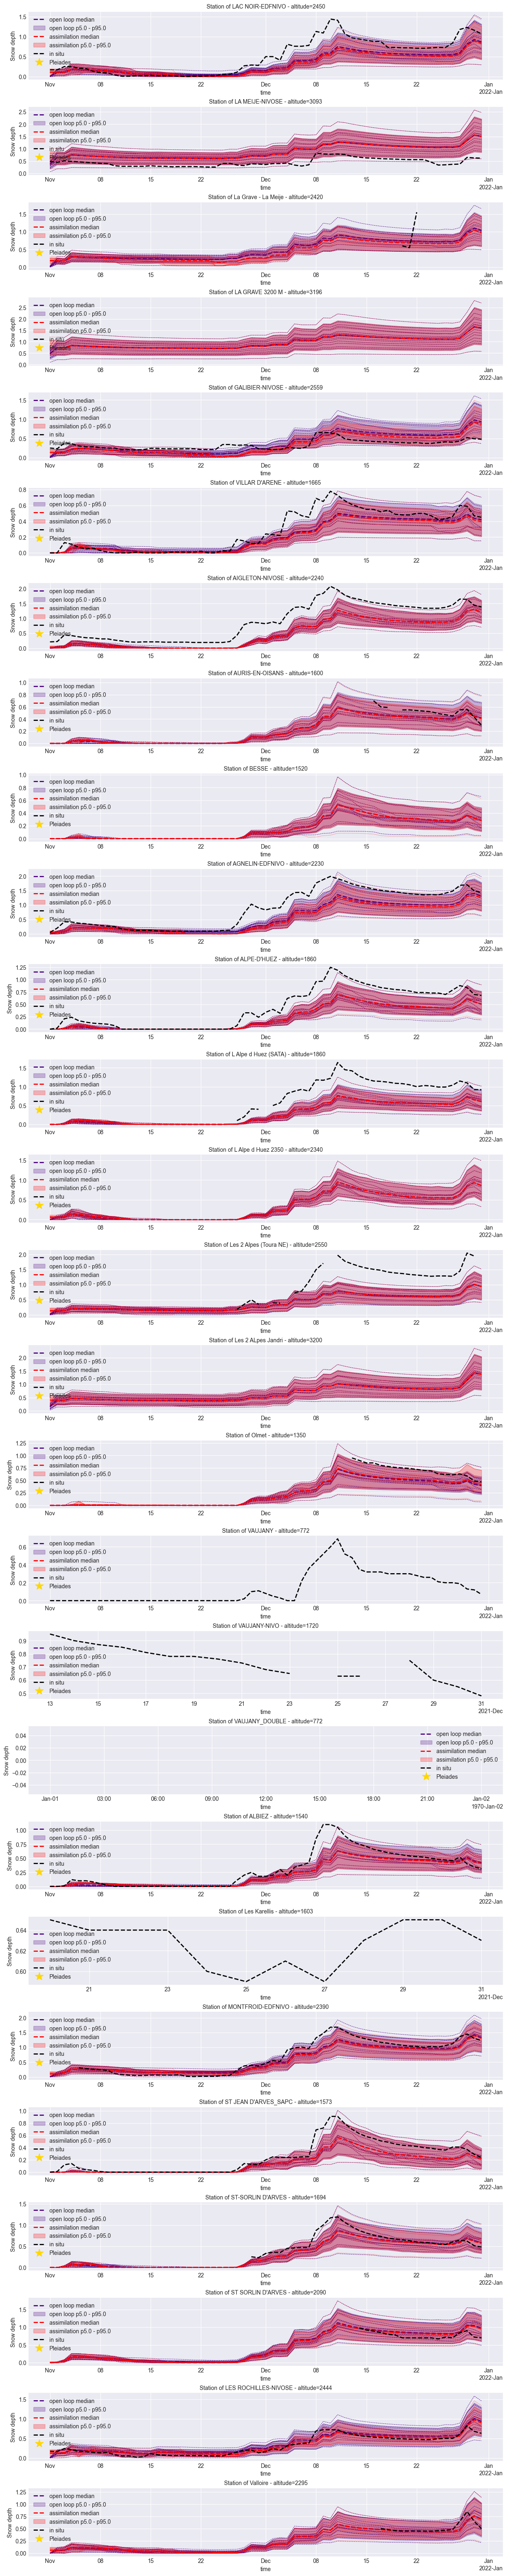

: 

In [ ]:
# EXPERIENCE VIIRS
import matplotlib.pyplot as plt


plt.style.use("seaborn-v0_8-darkgrid")
n_tot = bdclim.sizes["num_poste"]
# n_tot = 5
fig, axs = plt.subplots(n_tot, 1, figsize=(15, 3 * n_tot))
fig.subplots_adjust(hspace=0.4)
time = edel.coords["time"]
qmin, qmax = 0.05, 0.95
for pp in range(n_tot):
    ax = axs[pp]
    xi, yi = x_poste[pp], y_poste[pp]
    open_loop_sd_median = edel.sel(x=xi, y=yi, method="nearest").mean(dim="member")
    open_loop_sd_p5 = edel.sel(x=xi, y=yi, method="nearest").quantile(q=qmin, dim="member")
    open_loop_sd_p95 = edel.sel(x=xi, y=yi, method="nearest").quantile(q=qmax, dim="member")

    assim_sd_median = edel_assim.sel(x=xi, y=yi, method="nearest").mean(dim="member")
    assim_sd_qmin = edel_assim.sel(x=xi, y=yi, method="nearest").quantile(q=qmin, dim="member")
    assim_sd_qmax = edel_assim.sel(x=xi, y=yi, method="nearest").quantile(q=qmax, dim="member")

    bdclim_poste = bdclim.where(bdclim["x"] == xi, drop=True).where(bdclim["y"] == yi, drop=True)
    pleiades_obs = pleiades.sel(x=xi, y=yi, method="nearest")

    open_loop_until_assim = edel.sel()
    ax.plot(time, open_loop_sd_median, color="indigo", linestyle="dashed", linewidth=2, label="open loop median")
    edel.sel(x=xi, y=yi, method="nearest").plot.line(x="time", ax=ax, color="indigo", linestyle="dashed", linewidth=0.6)
    ax.fill_between(
        time, open_loop_sd_p5, open_loop_sd_p95, color="indigo", alpha=0.25, label=f"open loop p{qmin * 100} - p{qmax * 100}"
    )

    ax.plot(
        edel_assim.coords["time"], assim_sd_median, color="red", linestyle="dashed", linewidth=2, label="assimilation median"
    )
    edel_assim.sel(x=xi, y=yi, method="nearest").plot.line(x="time", ax=ax, linestyle="dotted", color="r", linewidth=0.6)
    ax.fill_between(
        edel_assim.coords["time"],
        assim_sd_qmin,
        assim_sd_qmax,
        color="red",
        alpha=0.25,
        label=f"assimilation p{qmin * 100} - p{qmax * 100}",
    )

    ax.plot(time, bdclim_poste.values, color="black", linestyle="dashed", linewidth=2, label="in situ")
    ax.plot(pleiades_obs.time, pleiades_obs.values, marker="*", linewidth=0, markersize=15, color="gold", label="Pleiades")
    ax.legend()
    ax.set_ylabel("Snow depth")
    ax.set_title(
        f"Station of {bdclim_poste.coords['Station_Name'].values[0]} - altitude={bdclim_poste.coords['ZS'].values[0]}",
        fontsize=10,
    )
    ax.grid(True)

In [26]:
sentinel_2.sel(x=xi, y=yi, method="nearest")

<xarray.DataArray 'snow_cover_fraction' (time: 13)> Size: 52B
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
      dtype=float32)
Coordinates:
    y            float64 8B 5.015e+06
    x            float64 8B 7.727e+05
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 104B 2021-11-05 2021-11-15 ... 2021-12-30

In [ ]:
from pyproj import CRS, Transformer, transform, Proj

trans = Transformer.from_crs(2154, 32631)
# (source_crs=CRS.from_epsg(32631), target_crs=CRS.from_epsg(2154))
# Transformer(CRS.from_epsg(32631), CRS.from_epsg(2154))

In [45]:
xi_s2, yi_s2

(1182105.9649606987, 7912519.54636936)

/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edelweiss_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered

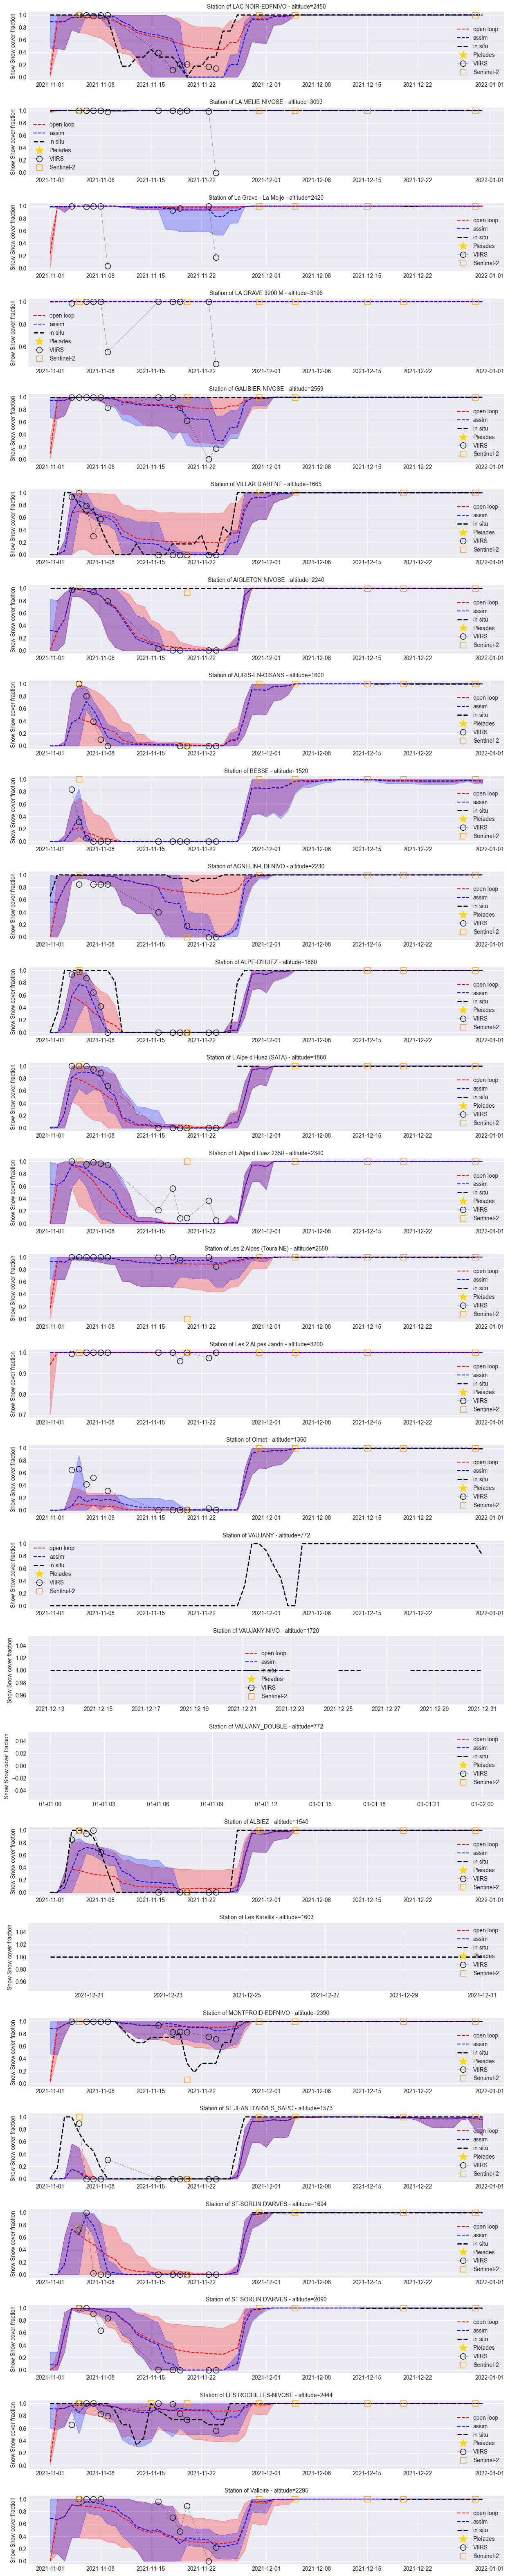

In [ ]:
# EXPERIENCE VIIRS - ASSIM FSC
import matplotlib.pyplot as plt
import numpy as np
from edelassim.observation_operators import dickinson
from edelassim.swe import sd_to_swe
from pyproj import CRS, Transformer

plt.style.use("seaborn-v0_8-darkgrid")
n_tot = bdclim.sizes["num_poste"]
# n_tot = 5
fig, axs = plt.subplots(n_tot, 1, figsize=(15, 3 * n_tot))
fig.subplots_adjust(hspace=0.4)
time = edel.coords["time"]
qmin, qmax = 0.05, 0.95
a_param = 2.1
for pp in range(n_tot):
    ax = axs[pp]
    xi, yi = x_poste[pp], y_poste[pp]

    bdclim_poste = bdclim.where(bdclim["x"] == xi, drop=True).where(bdclim["y"] == yi, drop=True)
    pleiades_obs = pleiades.sel(x=xi, y=yi, method="nearest")

    spaghettis_open_loop_fsc = dickinson(sd=edel.sel(x=xi, y=yi, method="nearest"), a=a_param, b=0.11)
    open_loop_fsc_mean = spaghettis_open_loop_fsc.mean(dim="member")
    open_loop_fsc_p5 = spaghettis_open_loop_fsc.quantile(q=qmin, dim="member")
    open_loop_fsc_p95 = spaghettis_open_loop_fsc.quantile(q=qmax, dim="member")
    ax.fill_between(edel.coords["time"], open_loop_fsc_p5, open_loop_fsc_p95, color="red", alpha=0.25)
    ax.plot(edel.coords["time"], open_loop_fsc_mean, linestyle="dashed", color="r", label="open loop", linewidth=1.5)

    spaghettis_assim_fsc = dickinson(sd=edel_assim.sel(x=xi, y=yi, method="nearest"), a=a_param, b=0.11)
    assim_fsc_mean = spaghettis_assim_fsc.mean(dim="member")
    assim_fsc_p5 = spaghettis_assim_fsc.quantile(q=qmin, dim="member")
    assim_fsc_p95 = spaghettis_assim_fsc.quantile(q=qmax, dim="member")
    ax.fill_between(edel_assim.coords["time"], assim_fsc_p5, assim_fsc_p95, color="blue", alpha=0.25)
    ax.plot(edel.coords["time"], assim_fsc_mean, linestyle="dashed", color="b", label="assim", linewidth=1.5)

    ax.plot(
        time,
        dickinson(sd=bdclim_poste.values, a=a_param, b=0.11),
        color="black",
        linestyle="dashed",
        linewidth=2,
        label="in situ",
    )
    ax.plot(
        pleiades_obs.time,
        dickinson(sd=pleiades_obs.values, a=a_param, b=0.11),
        marker="*",
        linewidth=0,
        markersize=15,
        color="gold",
        label="Pleiades",
    )
    ax.plot(
        viirs.time,
        viirs.sel(x=xi, y=yi, method="nearest"),
        marker="o",
        mfc="none",
        linewidth=0.2,
        markersize=10,
        color="black",
        label="VIIRS",
    )
    xi_s2, yi_s2 = trans.transform(xi, yi)
    ax.plot(
        sentinel_2.time,
        sentinel_2.sel(x=xi_s2, y=yi_s2, method="nearest"),
        marker="s",
        mfc="none",
        linewidth=0,
        markersize=10,
        color="orange",
        label="Sentinel-2",
    )

    ax.legend()
    ax.set_ylabel("Snow Snow cover fraction")
    ax.set_title(
        f"Station of {bdclim_poste.coords['Station_Name'].values[0]} - altitude={bdclim_poste.coords['ZS'].values[0]}",
        fontsize=10,
    )
    ax.grid(True)